## Supplementary Figure 5

Enviorment: env 1

In [1]:
import pandas as pd
import pickle
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary-AI-HDP/code/utils/")
from utils import get_test_pr, get_test_roc

In [ ]:
dpi = 300
font_size = 12
fig_size = 5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

In [3]:
fmf_probs = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results_104.csv")
fmf_probs["id"] = [id.lower() for id in fmf_probs["patient_id"]]
fmf_probs["first_preg"] = [int(val == "Nulliparous") for val in fmf_probs["input_obhist"]]
fmf_probs["prev_pec"] = [int(val == "Parous, prev PE") for val in fmf_probs["input_obhist"]]
fmf_probs["chtn"] = fmf_probs["input_hyp"].astype(int)

In [4]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_evaluation.pkl", "rb") as f:
    eval_data = pickle.load(file=f)
ghtn_cases = eval_data["ghtn"]
chtn_cases = eval_data["chtn"]
final_exclusions = eval_data["ex"]

66 13


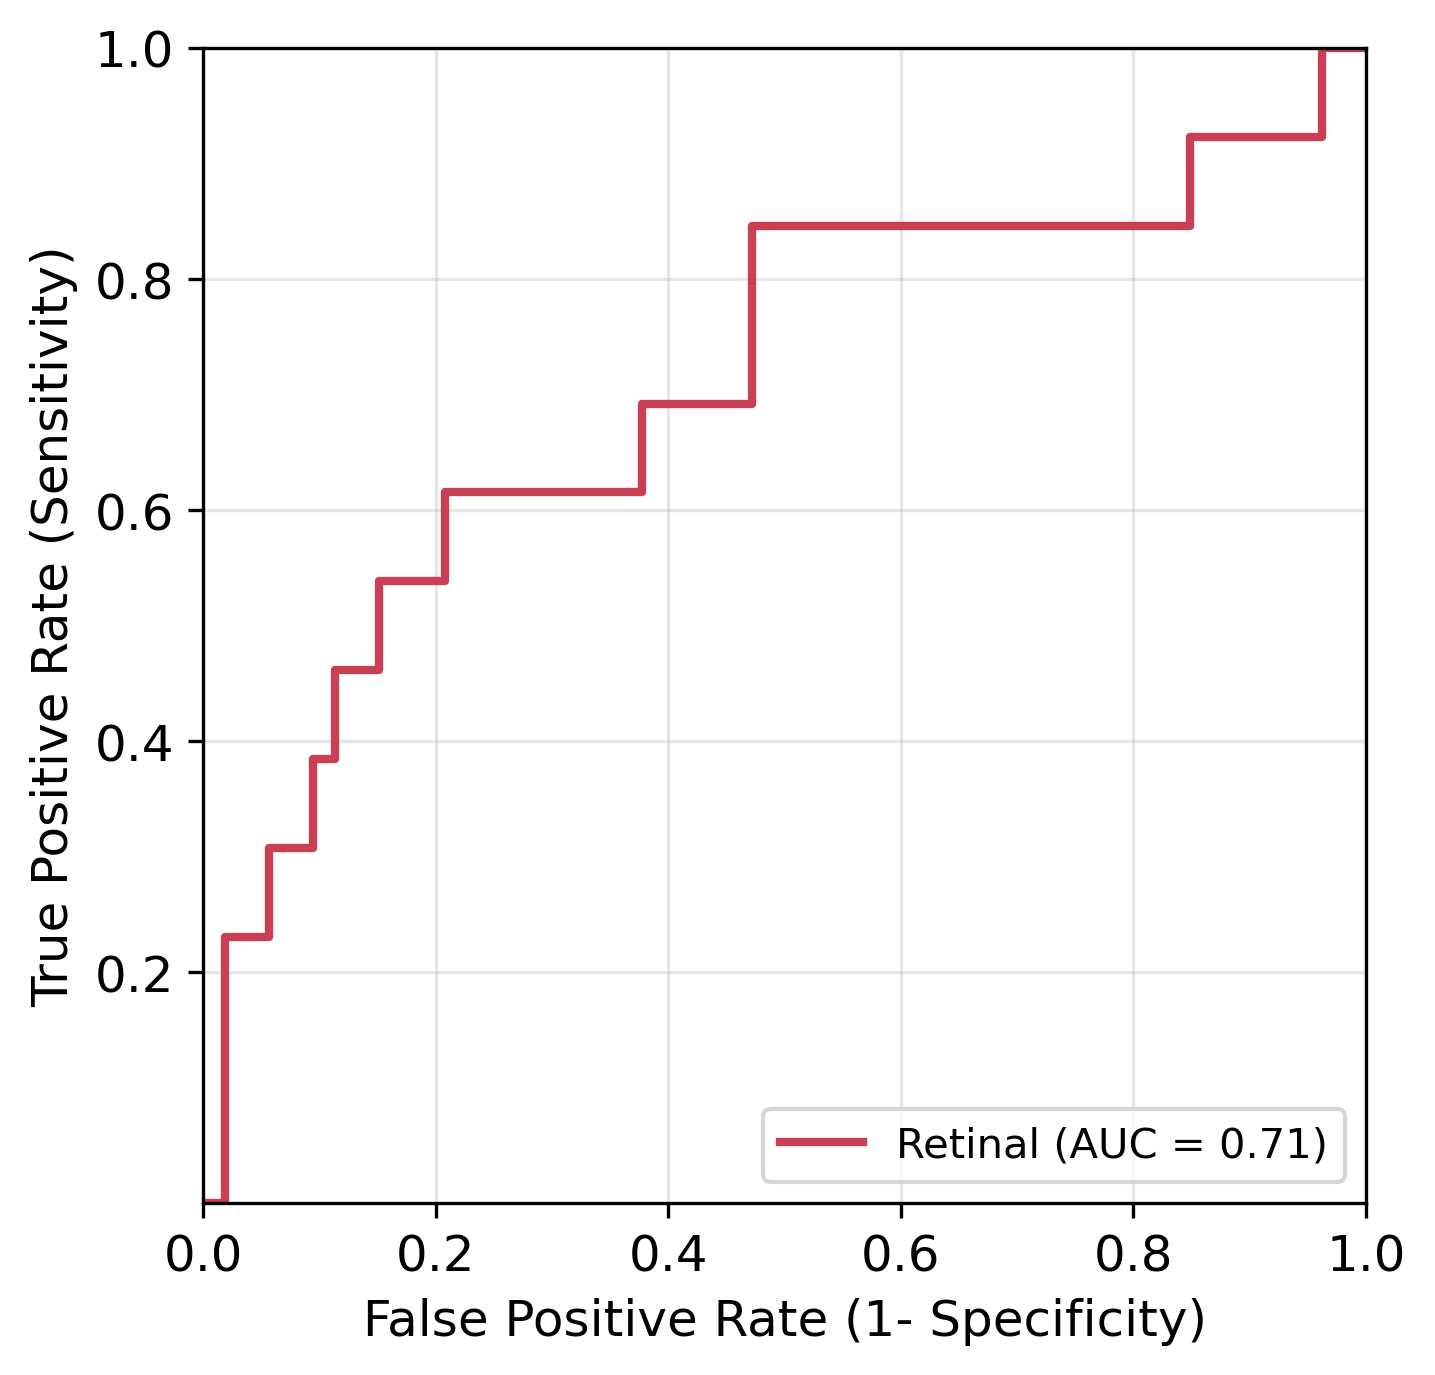

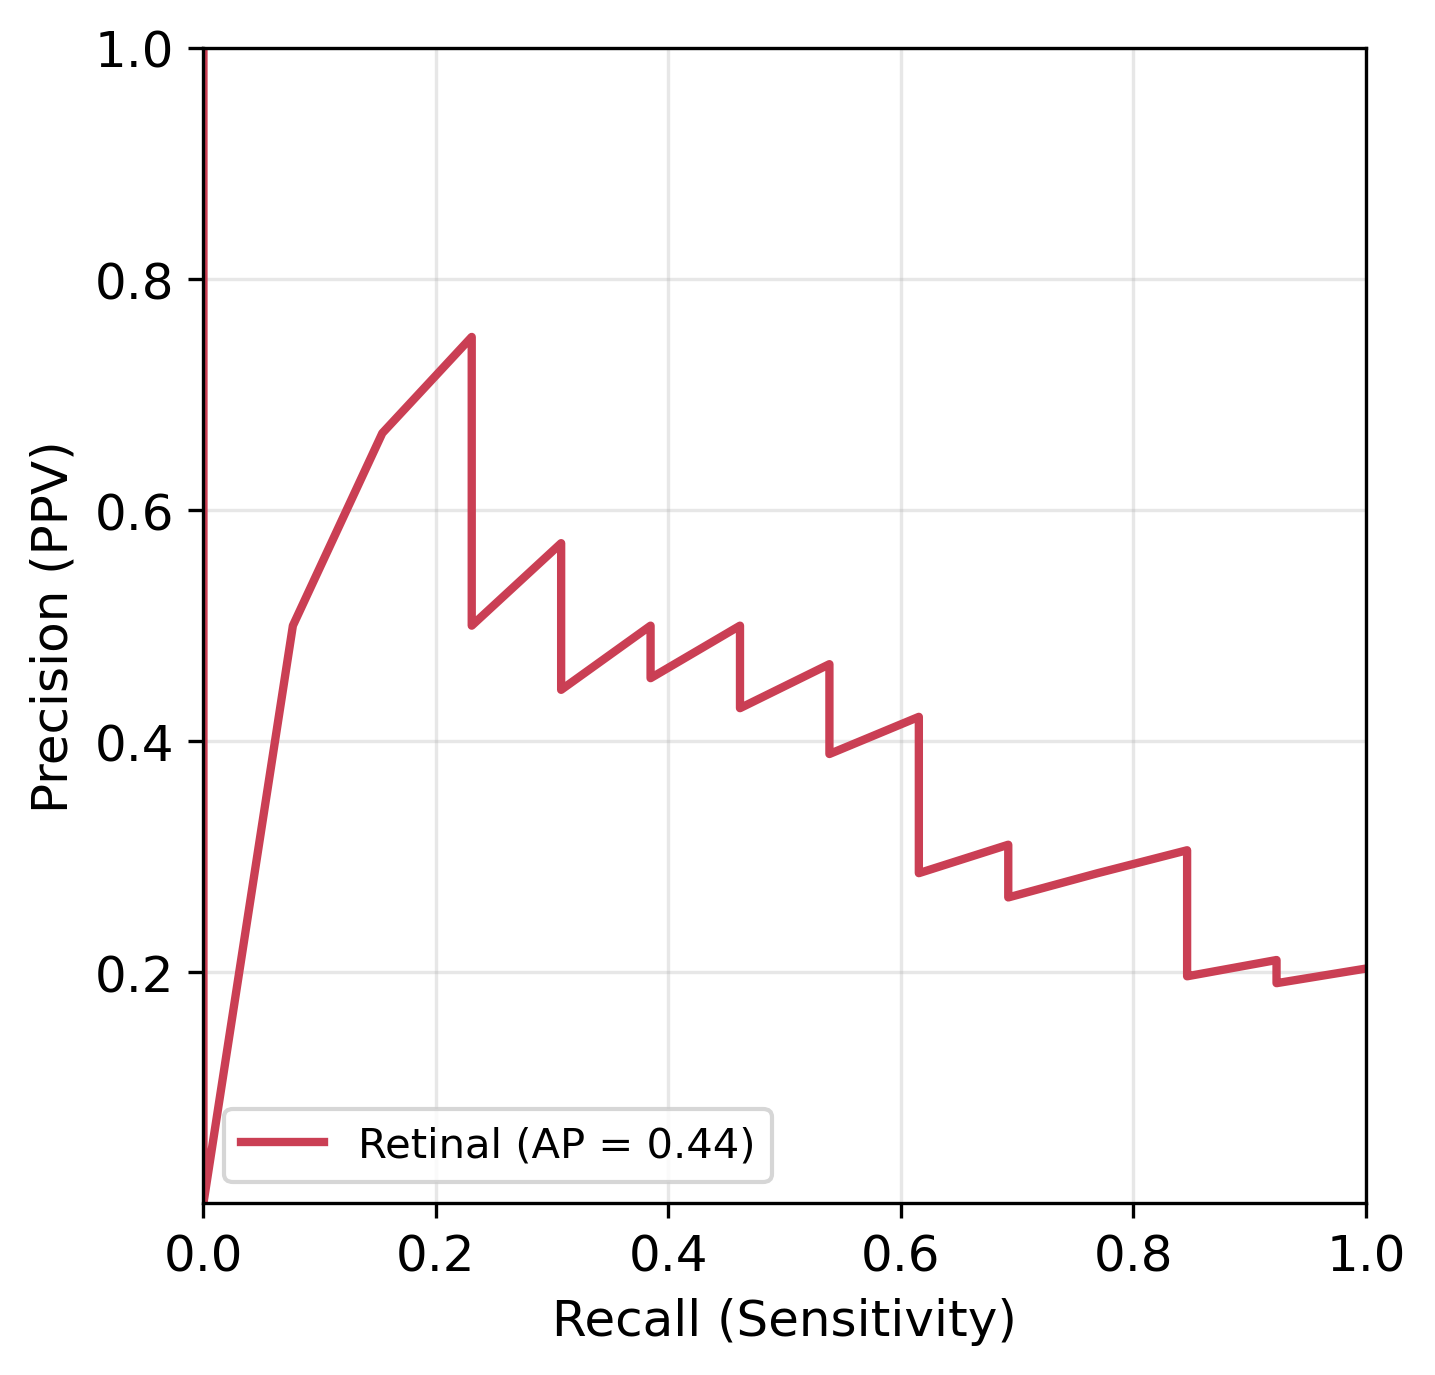

66 13


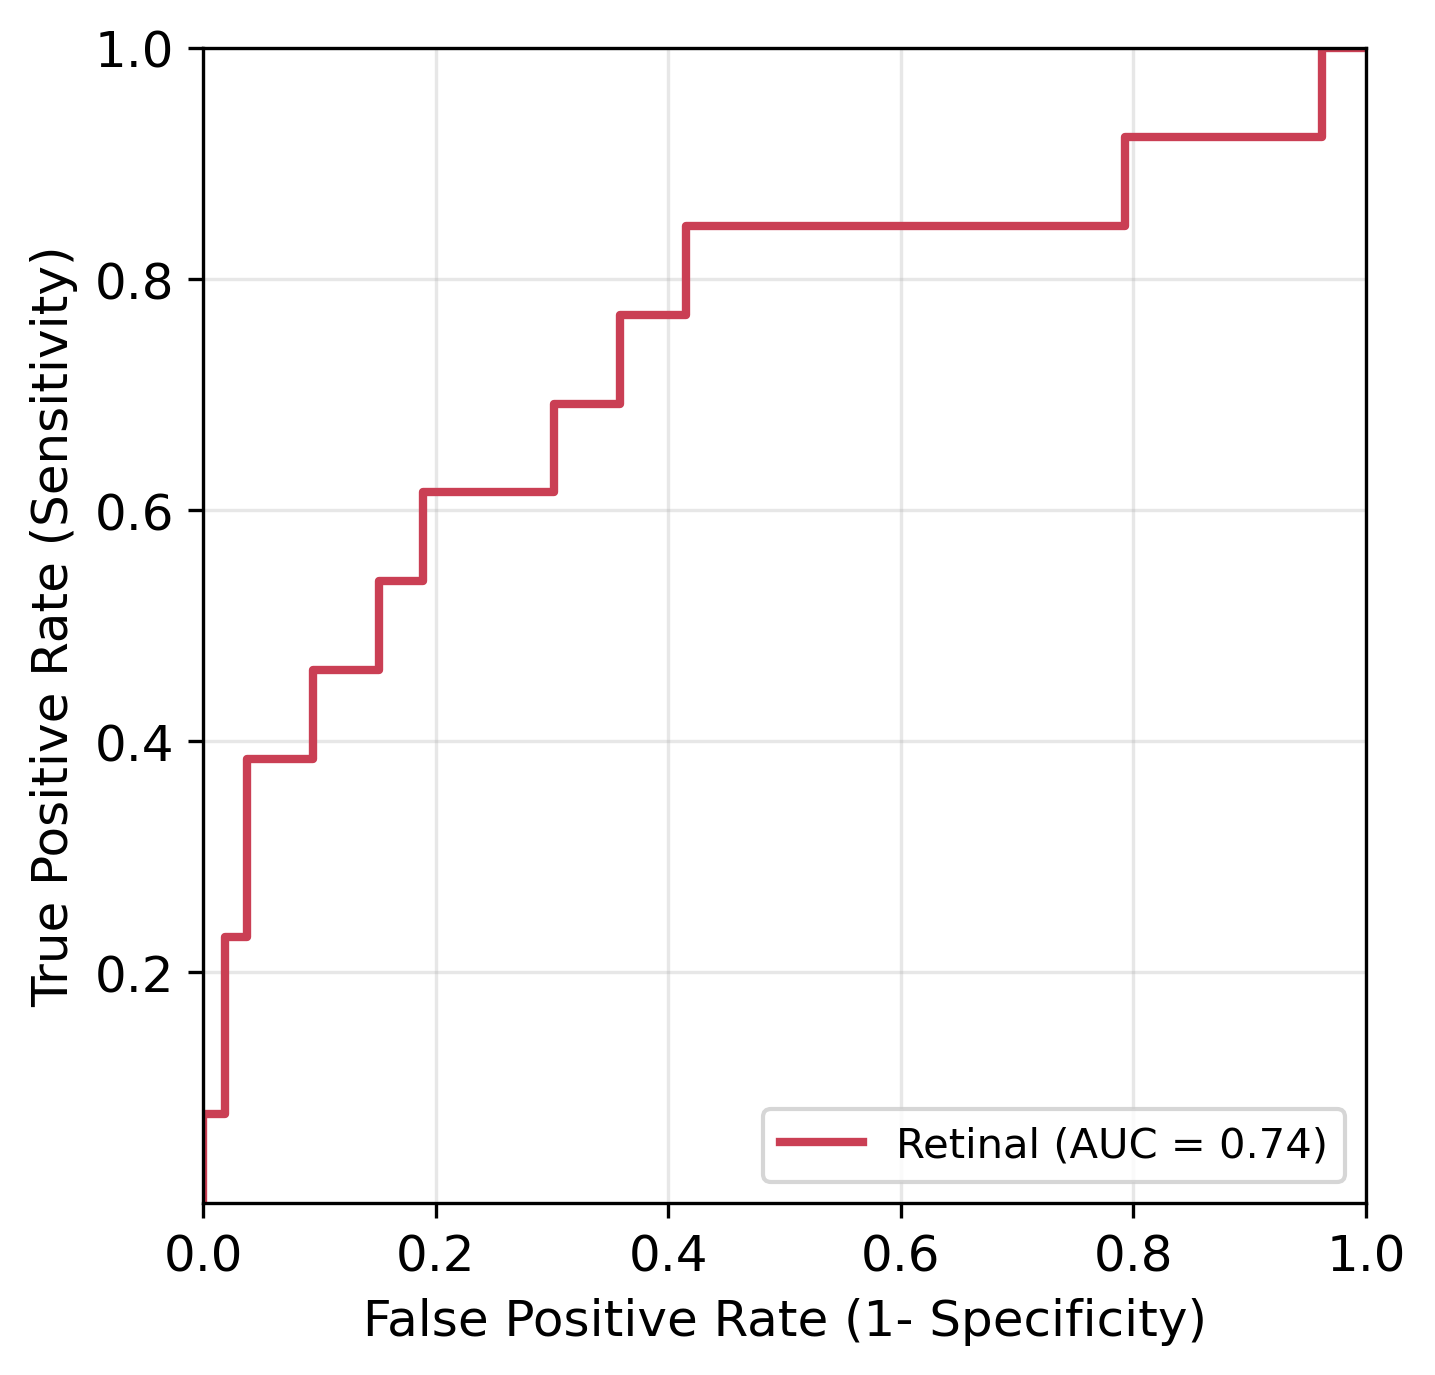

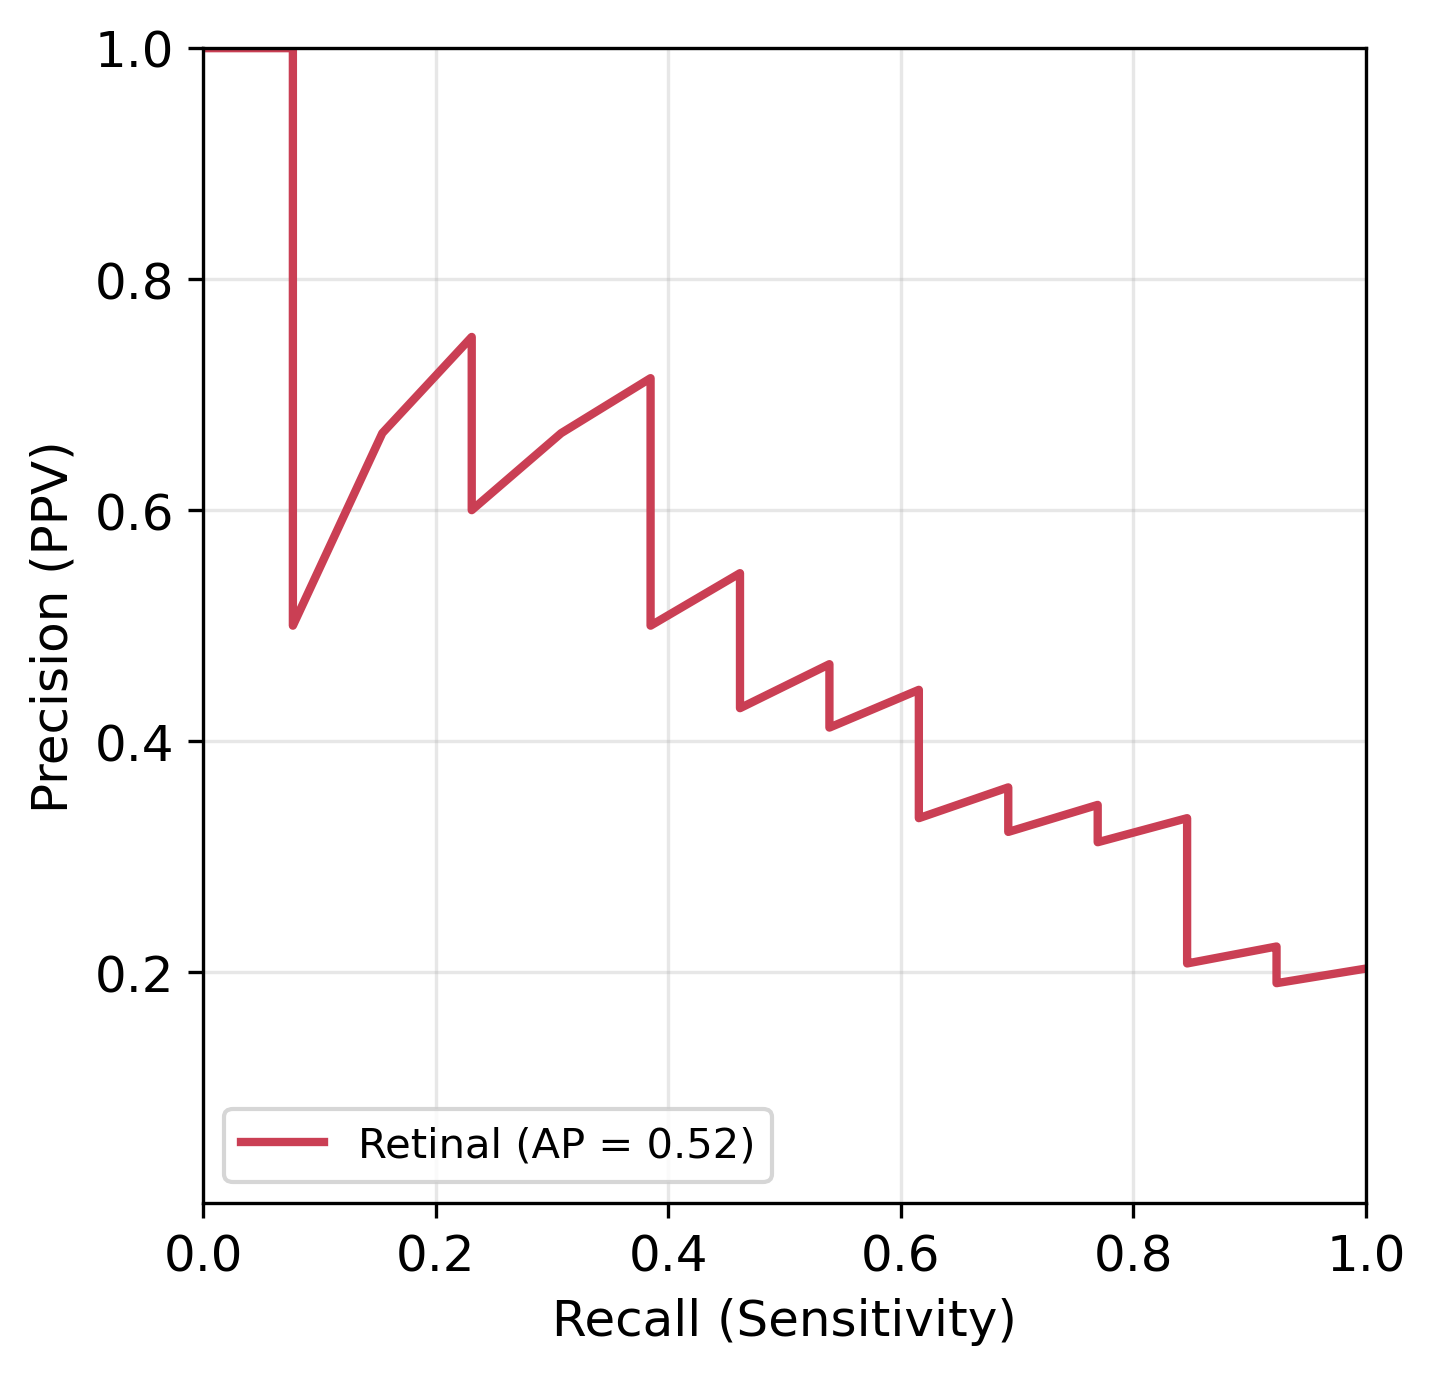

66 13


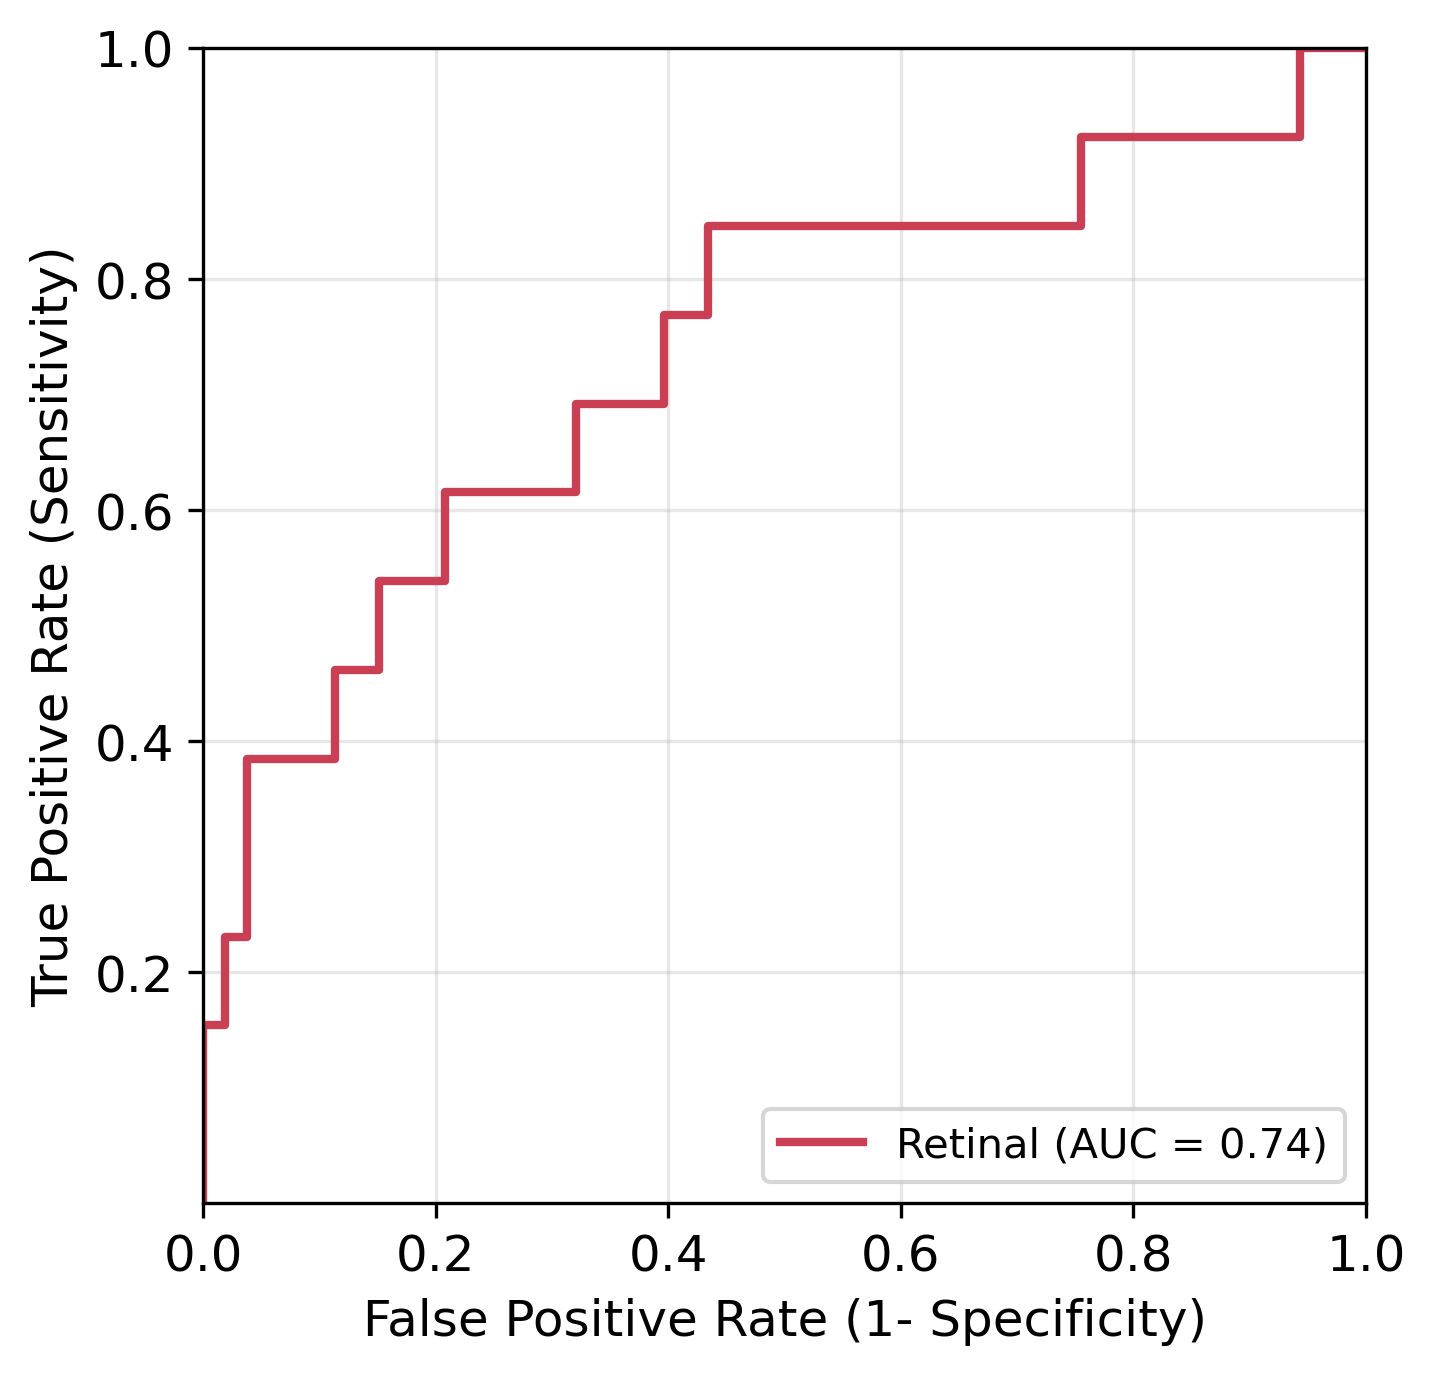

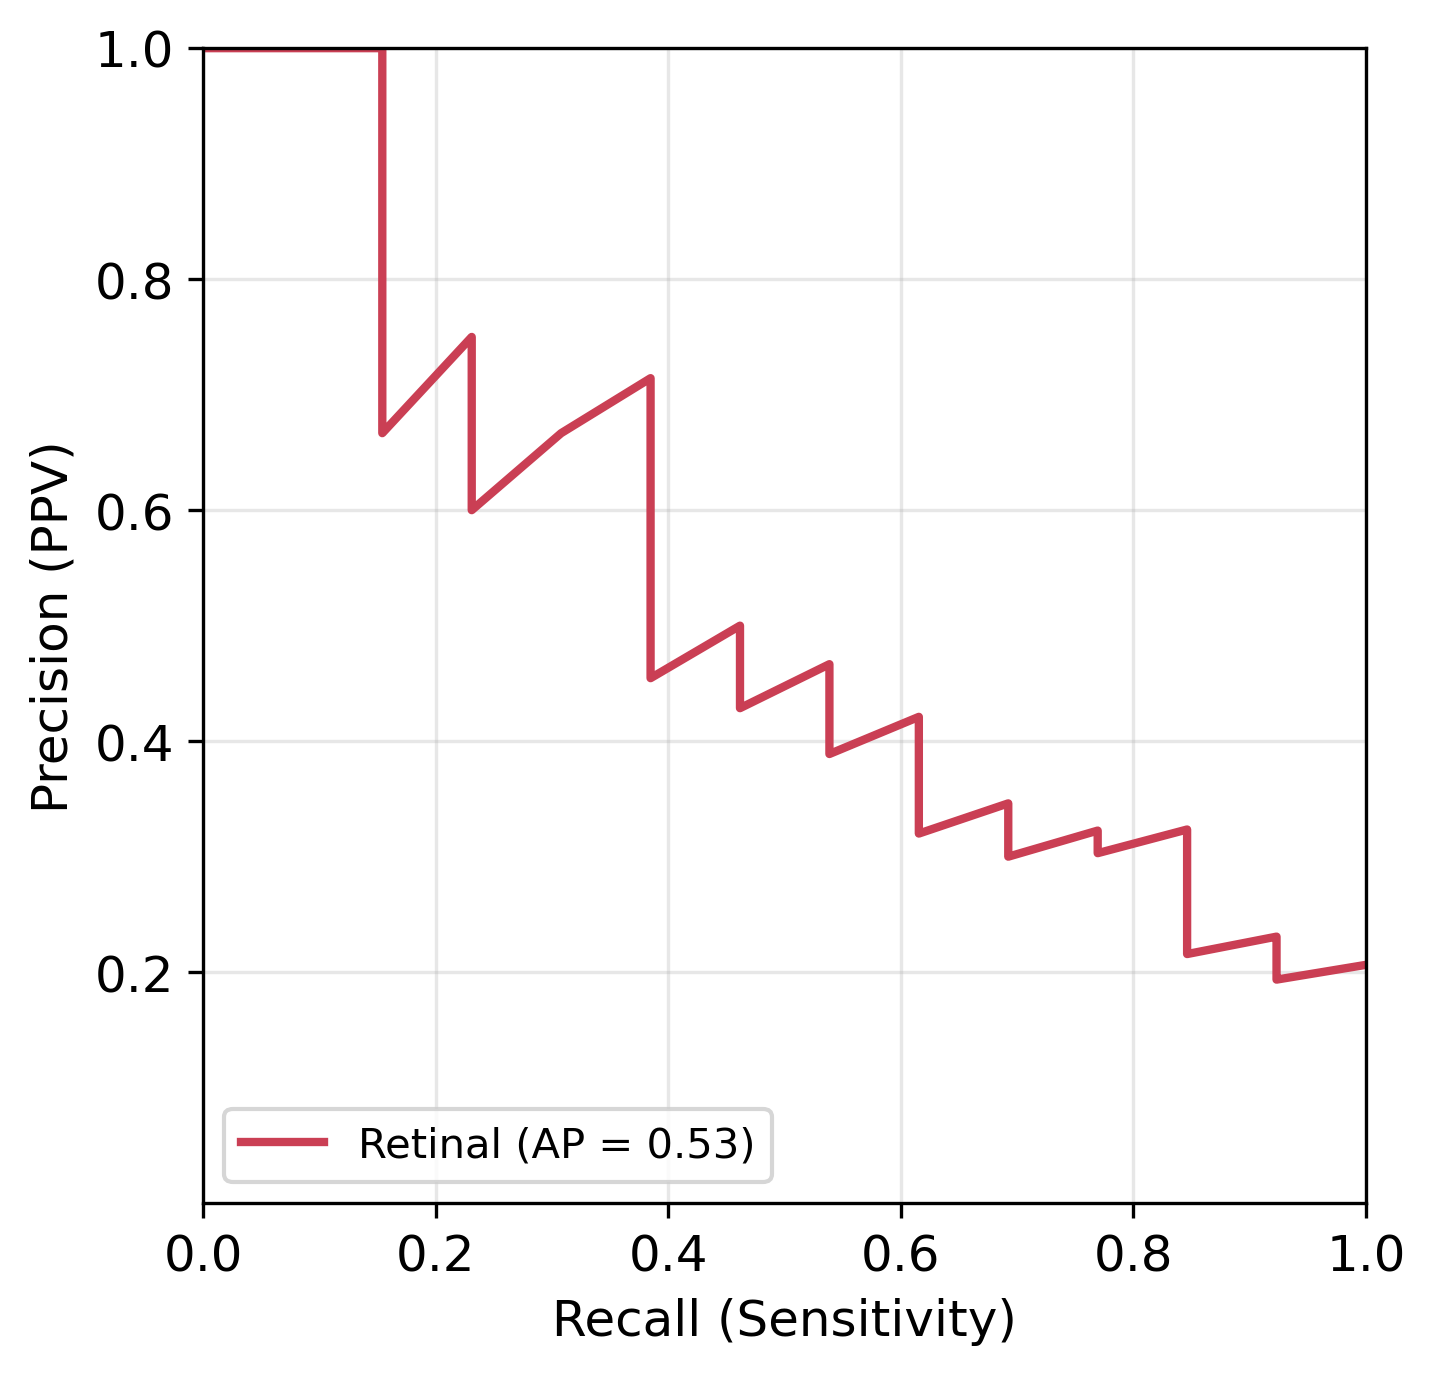

66 13


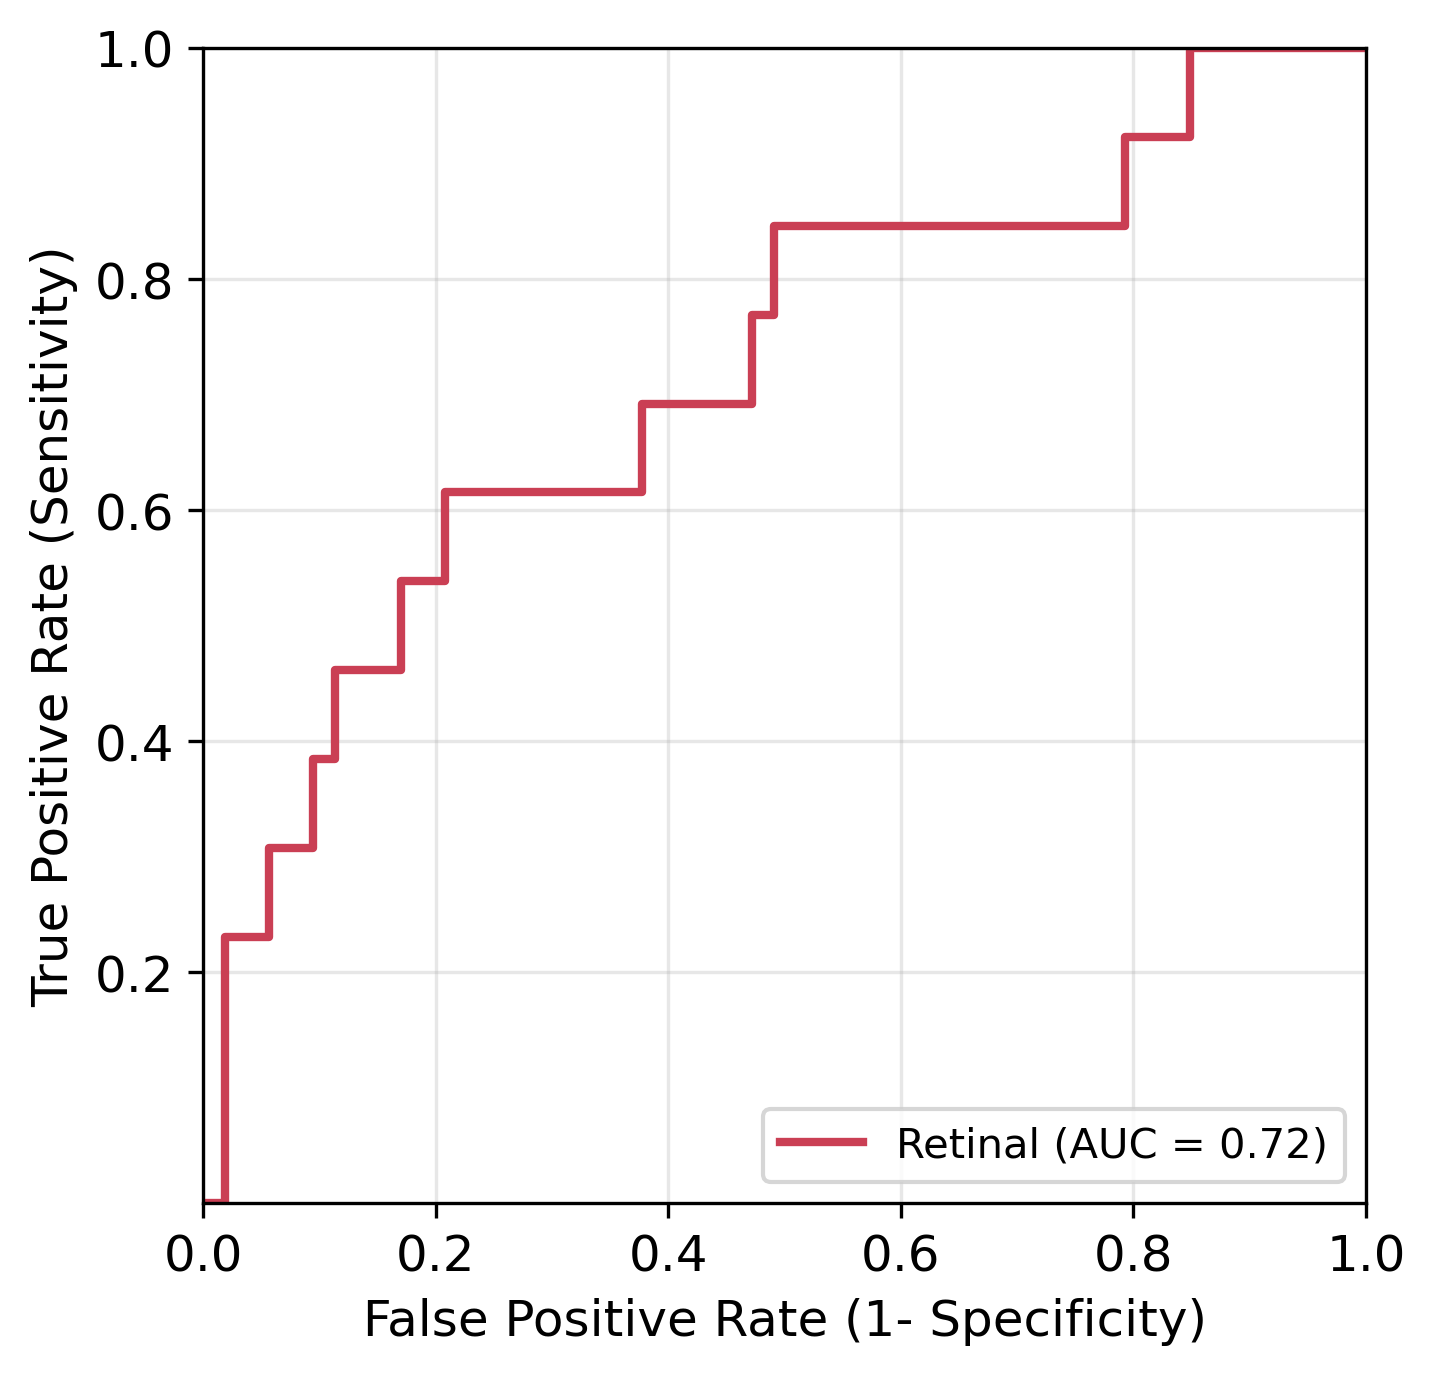

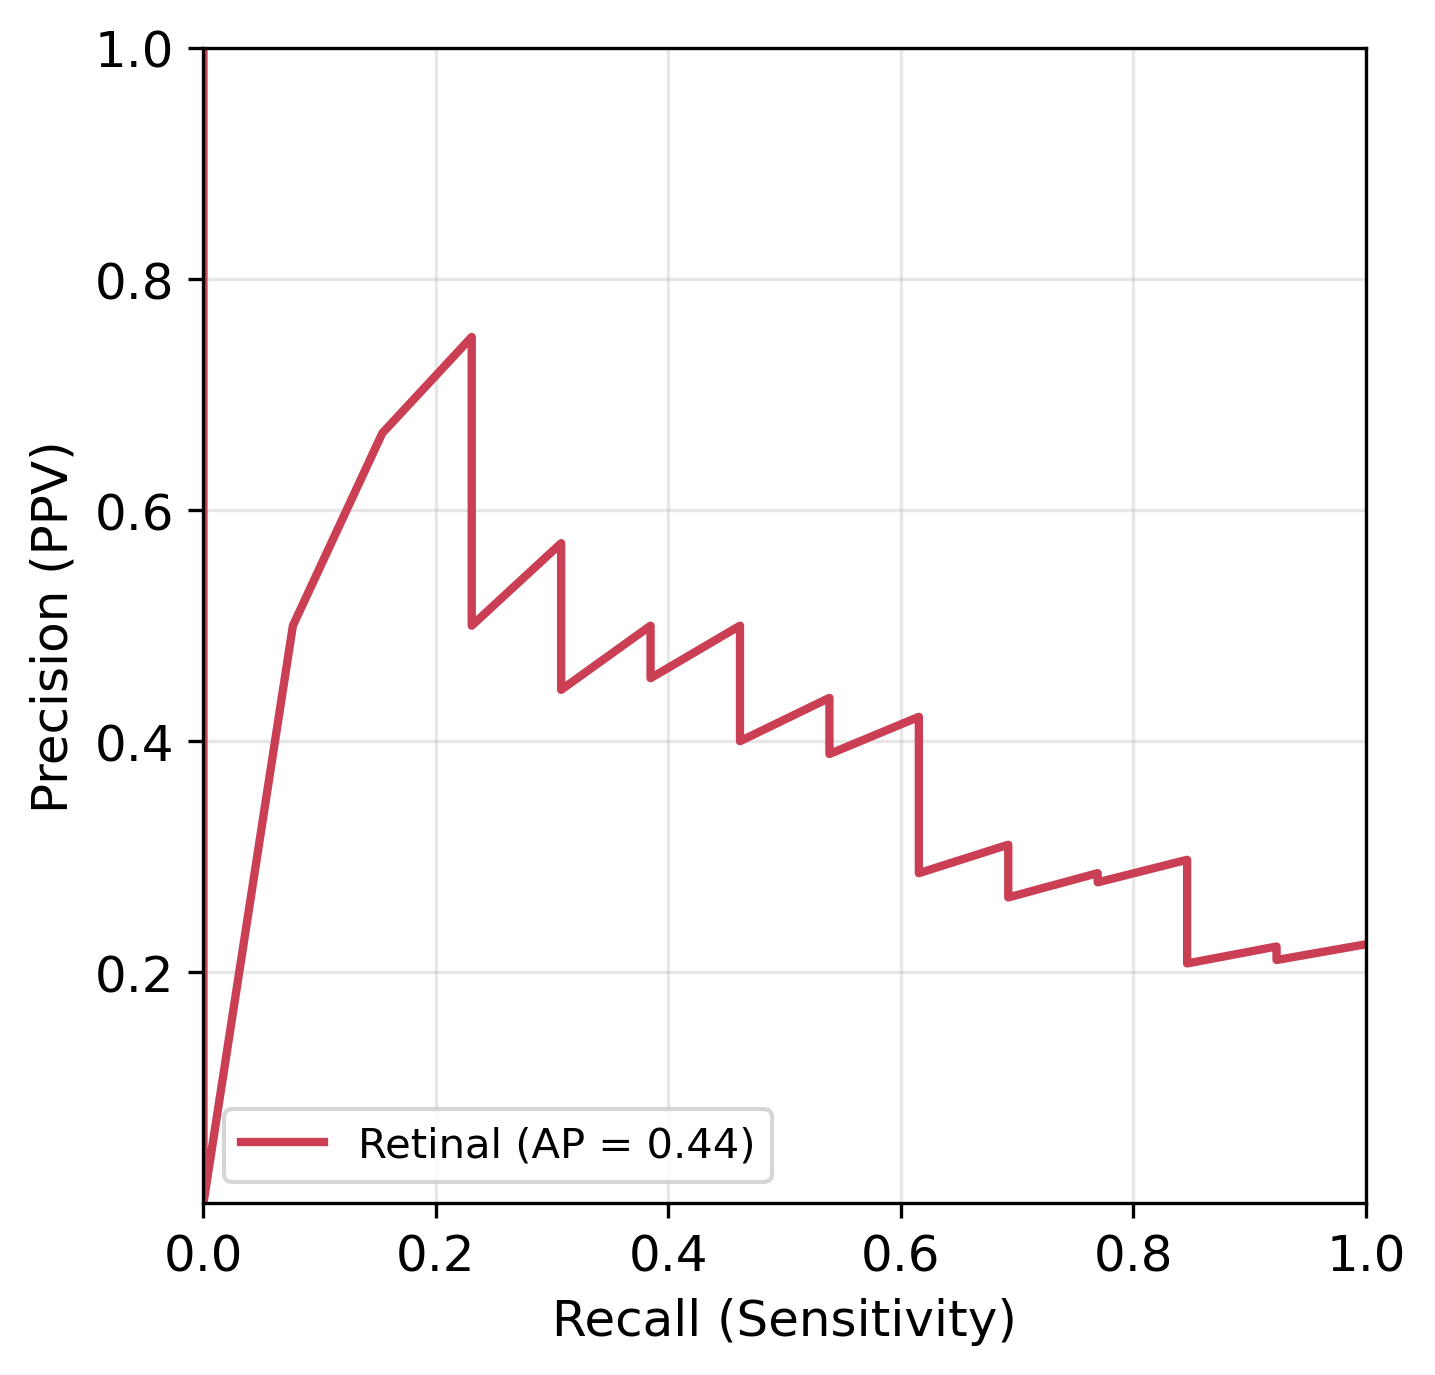

66 13


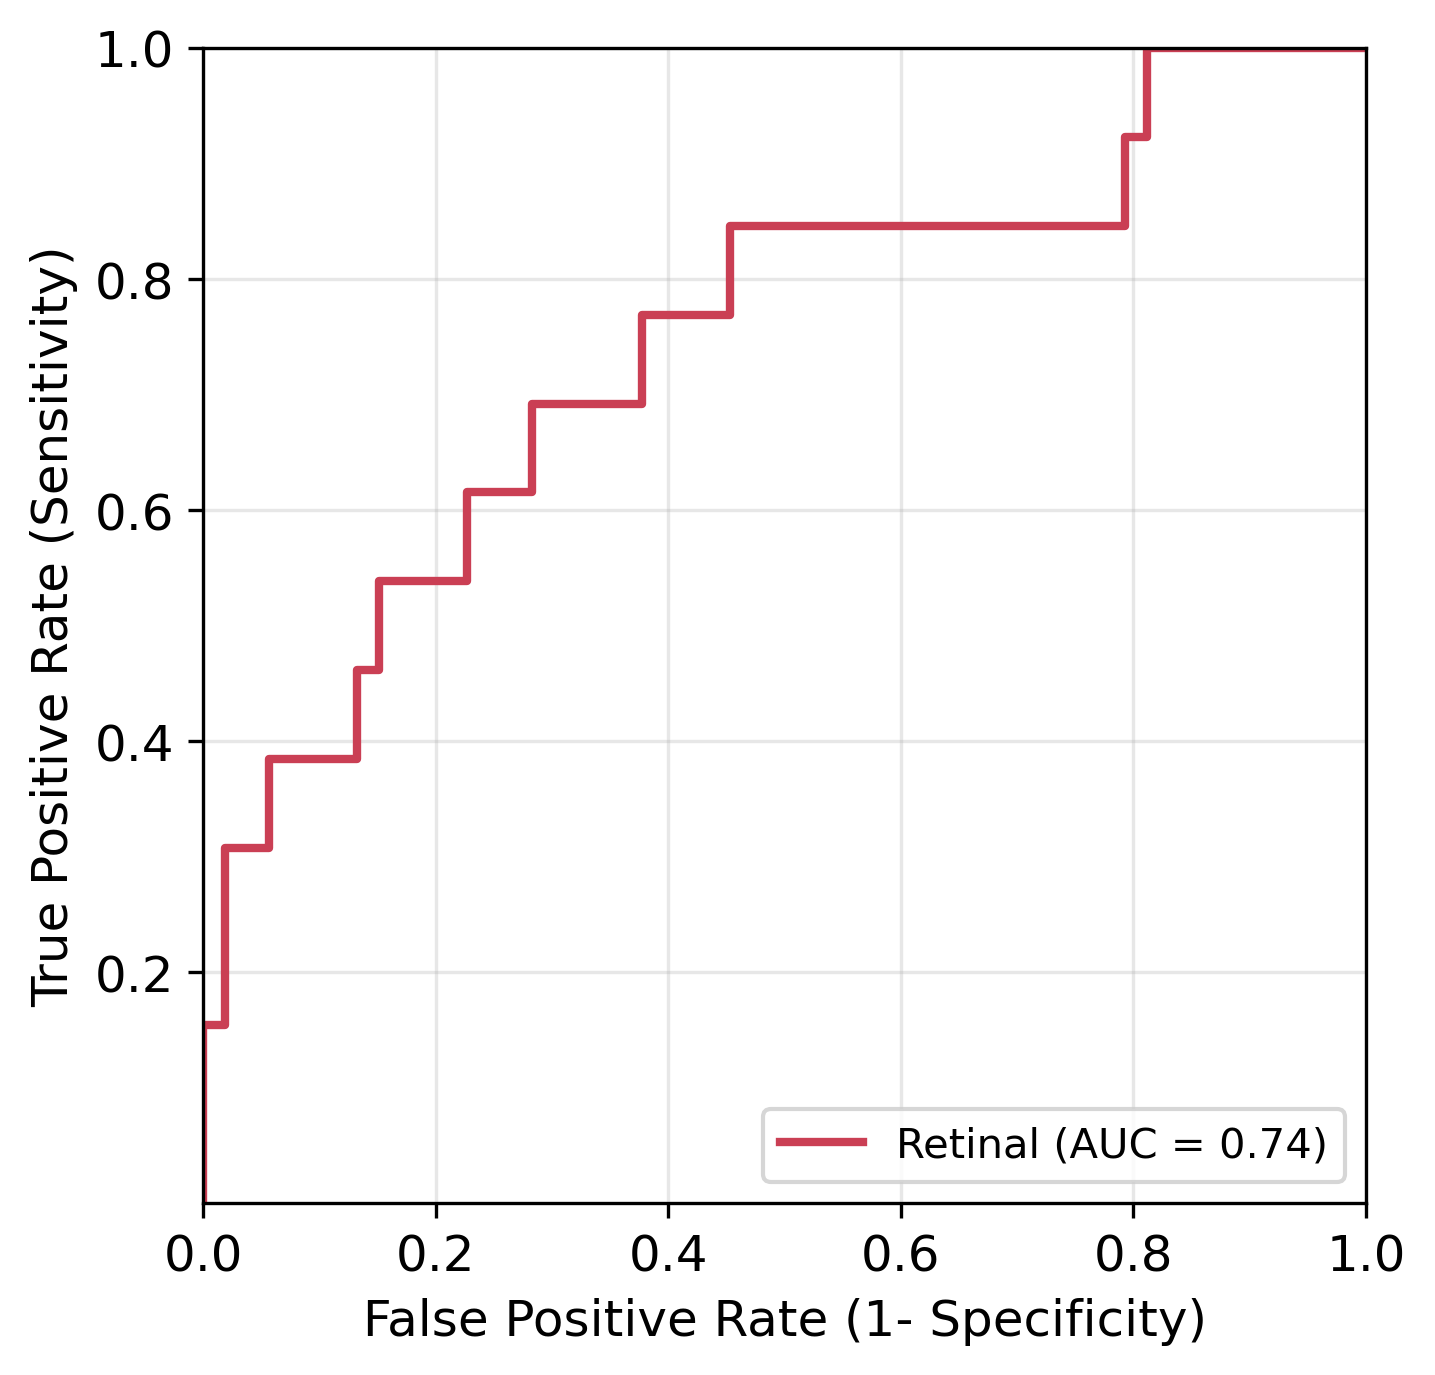

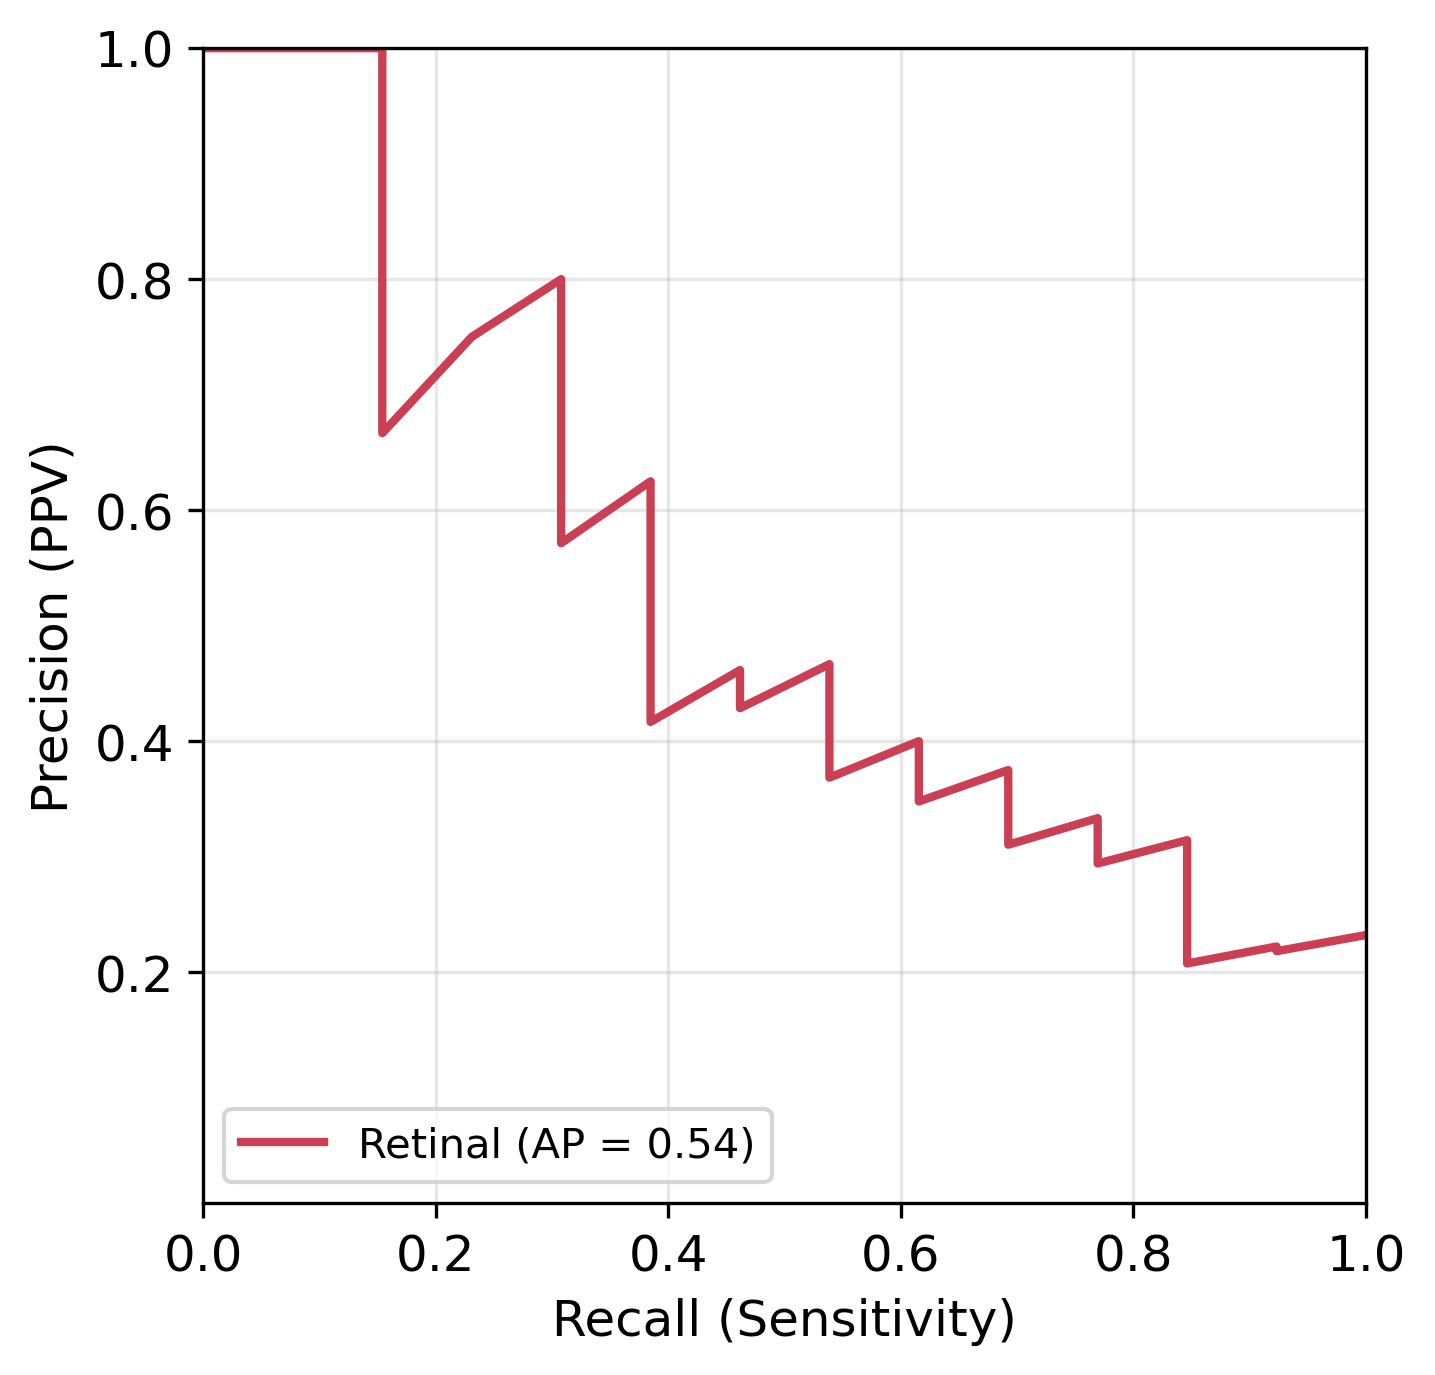

66 13


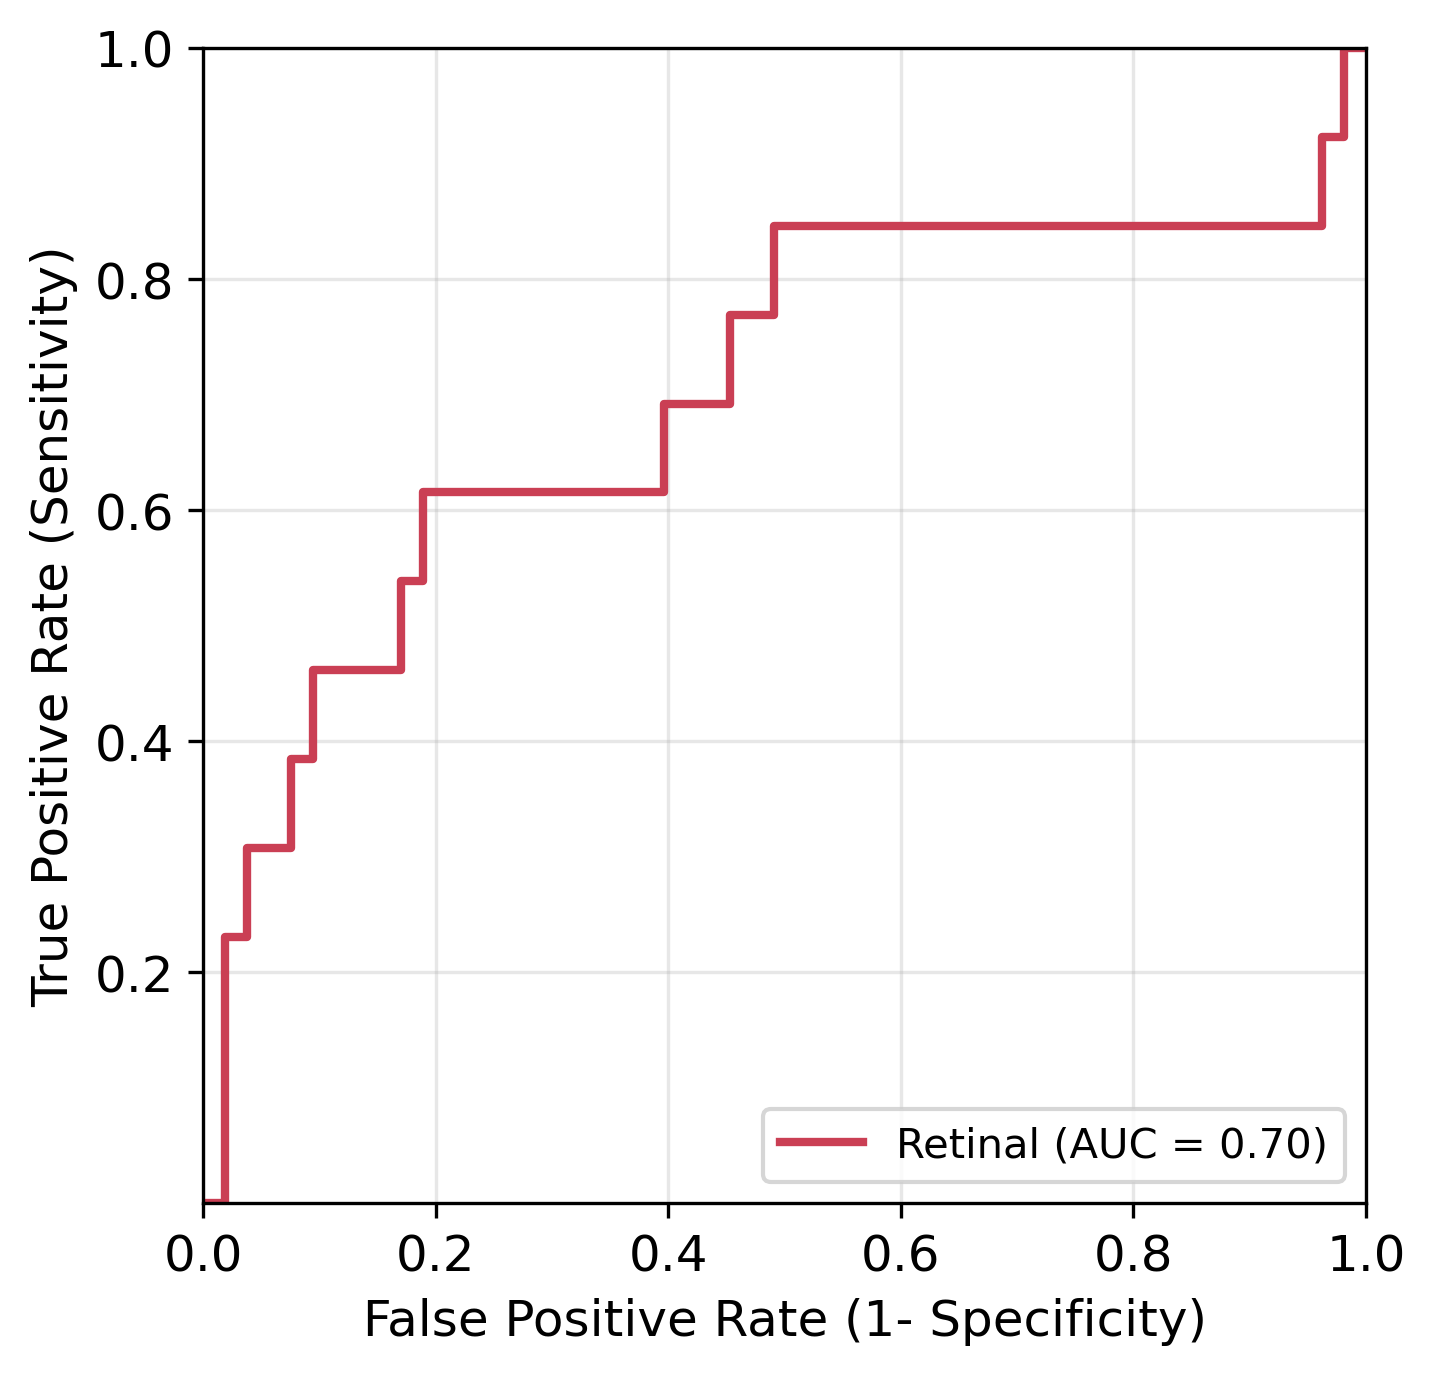

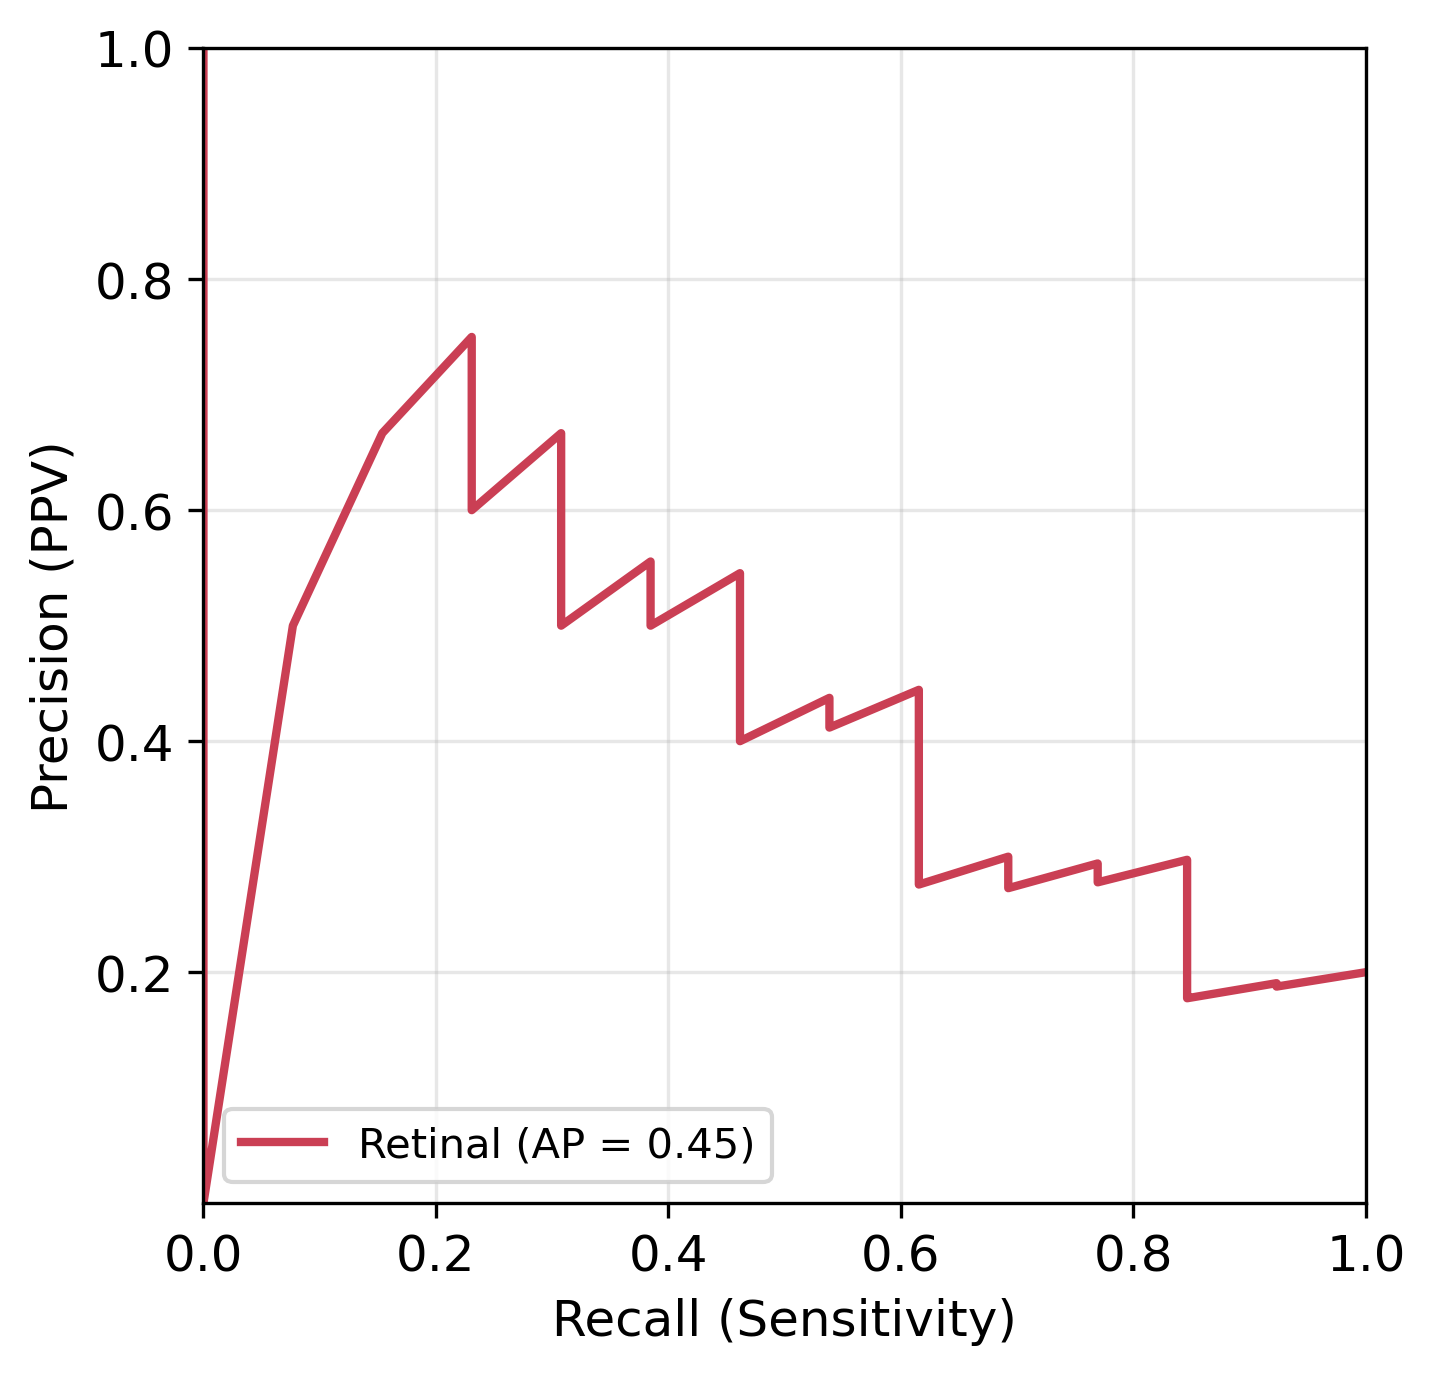

In [5]:
for run in ["eyelash_max", "eyelash_min", "art_min", "art_max", "dens_max", "dens_min"]:
    nyu_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/nyu/nyu_rg_delivered_testset/"
    all_probs = []
    for i in range(1, 6):
        path = nyu_path + f"nyu_79_no_repeats_med_{run}_pec_pw{i}/meta_all_0.5_oof_bls_pw{i}/XGBoost/"
        name = os.listdir(path)[0]
        with open(path + name, "rb") as f:
            data = pickle.load(f)
        all_probs.append(data[1])
    all_probs = pd.DataFrame(all_probs)

    retinal_probs = pd.DataFrame(all_probs.min(), columns=["retinal"])
    retinal_probs["id"] = retinal_probs.index
    retinal_probs = retinal_probs.reset_index(drop=True)
    retinal_probs = retinal_probs.merge(fmf_probs[["id", "pe_before_delivery_percent", "cohort", "first_preg", "prev_pec", "input_age"]], how="outer")
    retinal_probs["label"] = (retinal_probs["cohort"] == "case").astype(int)
    retinal_probs = retinal_probs.dropna()

    ids = list(set(retinal_probs["id"].values) - set(final_exclusions))
    print(len(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"]), sum(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"]))

    plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
    retinal_probs["combo"] = (retinal_probs["prev_pec"] * 0.35 + 0.15 *((retinal_probs["first_preg"]) * (retinal_probs["input_age"] > 37).astype(int)))
    get_test_roc(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal", color="#CA3F54")
    plt.savefig(f'/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_5/roc_{run}.pdf')
    plt.show()

    plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
    retinal_probs["combo"] = (retinal_probs["prev_pec"] * 0.35 + 0.15 *((retinal_probs["first_preg"]) * (retinal_probs["input_age"] > 37).astype(int)))
    get_test_pr(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] + (retinal_probs[retinal_probs["id"].isin(ids)].dropna()["combo"]), curve_label="Retinal", color="#CA3F54")
    plt.savefig(f'/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_5/pr_{run}.pdf') 
    plt.show()